In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestTrios, calculate3LegMetrics
# from MODELS.teamInfo import *

In [ ]:
import joblib


# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTION.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTION.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTION.pkl')

# Load isotonic regression calibrator (if available)
iso_calibrator_path = '../MODELS/SAVED_MODELS/NGBOOST_PTS_ISOTONIC_CALIBRATOR_PRODUCTION.pkl'
if os.path.exists(iso_calibrator_path):
    isotonic_calibrator = joblib.load(iso_calibrator_path)
    print("✓ Loaded isotonic regression calibrator")
else:
    isotonic_calibrator = None
    print("⚠ Isotonic calibrator not found - using uncalibrated predictions")

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor,
    'isotonic_calibrator': isotonic_calibrator
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Using isotonic calibration: {isotonic_calibrator is not None}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 1
Number of features: 127


In [3]:
pd.set_option('display.max_columns', None)

# s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

s26.sample(5)

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_48715/1829295019.py:5: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,matchupFieldGoalsPercentage,matchupThreePointersPercentage,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,TEAM_SEASON_ID,TEAM_NAME,TEAM_GAME_DATE,TEAM_MATCHUP,TEAM_WL,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,VIDEO_AVAILABLE,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS_AVG_TO_DATE,MATCHUP_PTS_DELTA,MATCHUP_AVG_MIN_TO_DATE,MIN_AVG_TO_DATE,MATCHUP_MIN_DELTA,MATCHUP_AVG_USG_PCT_TO_DATE,USG_PCT_AVG_TO_DATE,MATCHUP_USG_PCT_DELTA,MATCHUP_AVG_EFG_PCT_TO_DATE,EFG_PCT_AVG_TO_DATE,MATCHUP_EFG_PCT_DELTA,MATCHUP_AVG_TS_PCT_TO_DATE,TS_PCT_AVG_TO_DATE,MATCHUP_TS_PCT_DELTA,PLAYER_HOME_AVG_PTS_TO_DATE,PLAYER_AWAY_AVG_PTS_TO_DATE,PLAYER_HOME_PTS_DELTA,PLAYER_AWAY_PTS_DELTA,PLAYER_HOME_AVG_FGA_TO

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_54856/3488731641.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
14808,14808,14808,14808,Jrue Holiday,player_points,underdog,over,11.5,-137,Boston Celtics,Toronto Raptors,c5d4bea033d5df350953050bdcb5dbf6,2024-11-17T01:10:00Z,2024-11-16,NaN,NaN,NaN,over
34529,34529,34529,34529,Jaden Ivey,player_points,underdog,under,16.5,-137,Denver Nuggets,Detroit Pistons,efb1af33c4ee8c1152e9f4c8fa696aed,2024-12-29T02:10:00Z,2024-12-28,NaN,NaN,NaN,under
161954,161954,161954,73893,Jaren Jackson Jr,player_points,underdog,under,20.5,-137,Oklahoma City Thunder,Memphis Grizzlies,NaN,NaN,2025-03-28,game,26.5,108.0,under
38394,38394,38394,38394,Obi Toppin,player_points,underdog,over,8.5,-137,Indiana Pacers,Phoenix Suns,7c138909a671e2895ea58542823dde19,2025-01-05T00:10:00Z,2025-01-04,NaN,NaN,NaN,over
129225,129225,129225,31746,Jabari Smith,player_points,underdog,under,12.5,-137,Houston Rockets,Phoenix Suns,NaN,NaN,2025-03-13,game,10.5,-110.0,under


In [5]:
backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')
s26_other = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251106.csv')
s26_other1 = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251107.csv')
backtestData = pd.concat([backtestData, s26_other, s26_other1])

backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
                            (backtestData['CATEGORY'] == 'player_points')]
backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
backtestData

,Unnamed: 0,BOOKMAKER,CATEGORY,NAME,SIDE,LINE,ODDS,GAME_DATE,LAST_UPDATE,version https://git-lfs.github.com/spec/v1
0,0.0,Underdog,player_points,Pascal Siakam,Over,26.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
1,1.0,Underdog,player_points,Pascal Siakam,Under,26.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
2,2.0,Underdog,player_points,Kristaps Porzingis,Over,18.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
3,3.0,Underdog,player_points,Kristaps Porzingis,Under,18.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
4,4.0,Underdog,player_points,Aaron Nesmith,Over,15.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
...,...,...,...,...,...,...,...,...,...,...
583,NaN,Underdog,player_points,Isaiah Hartenstein,Under,9.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN
584,NaN,Underdog,player_points,Isaiah Joe,Over,12.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN
585,NaN,Underdog,player_points,Isaiah Joe,Under,12.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN
586,NaN,Underdog,player_points,Ajay Mitchell,Over,16.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN


In [16]:
date = '2025-11-04'

results = backtestTrios(
    data=s26,
    backtestData=backtestData,
    gameDate=date,
    models=models,  
    features=features,
    edge_threshold=0.25, 
    top_n=5, 
    variance_inflation=1.1, 
    distribution_type='t', stat_col='PTS', 
    use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=10)

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("TRIO BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['parlay_won'].sum()
    win_rate = results['parlay_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['parlay_profit'].sum() 
    avg_profit = results['parlay_profit'].mean() 
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

TRIO BETTING RESULTS ANALYSIS
Total Bets: 5
Wins: 2
Win Rate: 40.00%
Total Profit: $70.00
Average Profit per Bet: $14.00


,NAME 1,NAME 2,NAME 3,LINE 1,LINE 2,LINE 3,PREDICTION 1,PREDICTION 2,PREDICTION 3,MODEL SIDE 1,MODEL SIDE 2,MODEL SIDE 3,PROB 1,PROB 2,PROB 3,PROB ALL THREE,EDGE 1,EDGE 2,EDGE 3,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,CONFIDENCE INTERVAL 1,CONFIDENCE INTERVAL 2,CONFIDENCE INTERVAL 3,INTERVAL WIDTH 1,INTERVAL WIDTH 2,INTERVAL WIDTH 3,SIGMA 1,SIGMA 2,SIGMA 3,SIGMA FLAG 1,SIGMA FLAG 2,SIGMA FLAG 3,EXPECTED ROI,SIMULATION METHOD,actual1,actual2,actual3,leg1_won,leg2_won,leg3_won,parlay_won,parlay_recommendation,parlay_profit,date
0,Giannis Antetokounmpo,Myles Turner,John Collins,31.5,14.5,12.5,21.63,6.76,9.51,under,under,under,0.920,0.938,0.709,0.6119,0.342,0.360,0.131,0.419,26.72,0.534,1,"(6.5, 36.8)","(0.0, 17.4)","(0.0, 22.4)",30.31,17.37,22.35,7.73,5.41,6.55,High,Med,High,267.2,Analytical,22,10,17,1,1,0,0,1,-10.0,2025-11-04
1,Giannis Antetokounmpo,Myles Turner,Ivica Zubac,31.5,14.5,15.5,21.63,6.76,12.63,under,under,under,0.920,0.938,0.697,0.6009,0.342,0.360,0.118,0.408,26.06,0.521,1,"(6.5, 36.8)","(0.0, 17.4)","(0.0, 25.9)",30.31,17.37,25.87,7.73,5.41,6.75,High,Med,High,260.6,Analytical,22,10,7,1,1,1,1,1,50.0,2025-11-04
2,Giannis Antetokounmpo,Myles Turner,James Harden,31.5,14.5,22.5,21.63,6.76,20.70,under,under,under,0.920,0.938,0.613,0.5285,0.342,0.360,0.035,0.335,21.71,0.434,1,"(6.5, 36.8)","(0.0, 17.4)","(5.6, 35.8)",30.31,17.37,30.19,7.73,5.41,7.70,High,Med,High,217.1,Analytical,22,10,25,1,1,0,0,1,-10.0,2025-11-04
3,Myles Turner,Bobby Portis,John Collins,14.5,10.5,12.5,6.76,7.14,9.51,under,under,under,0.938,0.783,0.709,0.5211,0.360,0.205,0.131,0.328,21.27,0.425,1,"(0.0, 17.4)","(0.0, 17.1)","(0.0, 22.4)",17.37,17.12,22.35,5.41,5.09,6.55,Med,Med,High,212.7,Analytical,10,2,17,1,1,0,0,1,-10.0,2025-11-04
4,Myles Turner,Bobby Portis,Ivica Zubac,14.5,10.5,15.5,6.76,7.14,12.63,under,under,under,0.938,0.783,0.697,0.5118,0.360,0.205,0.118,0.319,20.71,0.414,1,"(0.0, 17.4)","(0.0, 17.1)","(0.0, 25.9)",17.37,17.12,25.87,5.41,5.09,6.75,Med,Med,High,207.1,Analytical,10,2,7,1,1,1,1,1,50.0,2025-11-04


In [11]:
uniqueDates = sorted(s26['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestTrios(
        data=s26,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.12, 
        top_n=5, 
        variance_inflation=1.1, 
        distribution_type='t', stat_col='PTS', 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=5)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")

Processing 2025-10-21... 1/19
No bets found for 2025-10-21
  No results for 2025-10-21
Processing 2025-10-22... 2/19
No bets found for 2025-10-22
  No results for 2025-10-22
Processing 2025-10-23... 3/19
  ✓ Processed 5 bets
Processing 2025-10-24... 4/19
  ✓ Processed 5 bets
Processing 2025-10-25... 5/19
  ✓ Processed 5 bets
Processing 2025-10-26... 6/19
  ✓ Processed 5 bets
Processing 2025-10-27... 7/19
  ✓ Processed 5 bets
Processing 2025-10-28... 8/19
  ✓ Processed 5 bets
Processing 2025-10-29... 9/19
  ✓ Processed 5 bets
Processing 2025-10-30... 10/19
  ✓ Processed 5 bets
Processing 2025-10-31... 11/19
  ✓ Processed 5 bets
Processing 2025-11-01... 12/19
  ✓ Processed 5 bets
Processing 2025-11-02... 13/19
  ✓ Processed 5 bets
Processing 2025-11-03... 14/19
  ✓ Processed 5 bets
Processing 2025-11-04... 15/19
  ✓ Processed 5 bets
Processing 2025-11-05... 16/19
  ✓ Processed 5 bets
Processing 2025-11-06... 17/19
  ✗ Error: 'ev_percent'
Processing 2025-11-07... 18/19
  ✗ Error: 'ev_perc

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 75
   Wins: 33
   Hit Rate: 44.00%
   Total Profit: $615.00
   Total Staked: $375.00
   ROI: 164.00%
   Volatility: $50.96
   Max Drawdown: $-25.00
   Sharpe Ratio: 3.116

   PROBABILITY METRICS:
   Brier Score: 0.2915 (lower is better)
   Log Loss: 0.7811 (lower is better)
   AUC-ROC: 0.4116 (higher is better)
   Samples: 75


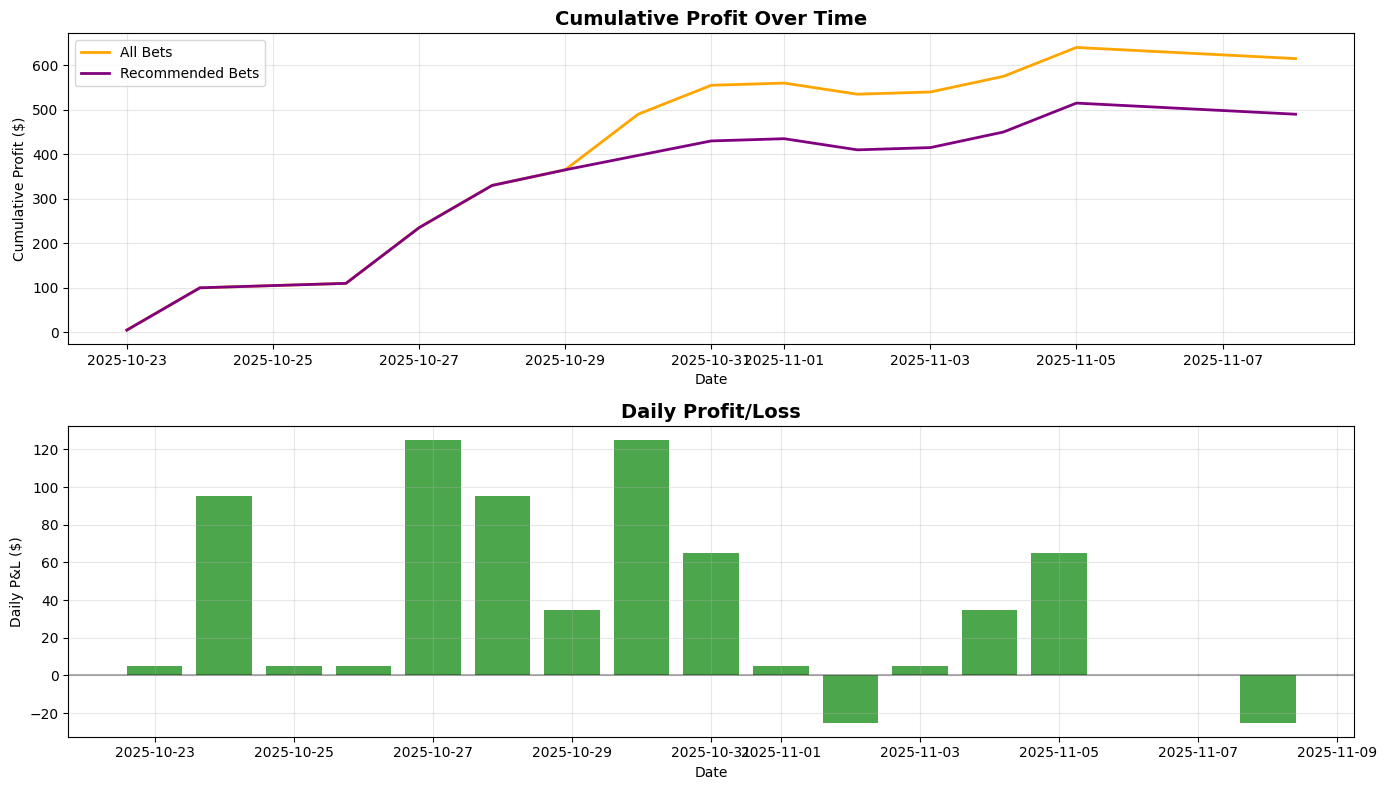

In [12]:
all_metrics = calculate3LegMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['parlay_recommendation'] == 1]
rec_metrics = calculate3LegMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
